# Feature Engineering

This notebook handles feature extraction and preprocessing for both domain and malware datasets.

## 1. Domain Feature Engineering

Load DGA domains from raw data and extract features.

In [43]:
pip install matplotlib


^C
Note: you may need to restart the kernel to use updated packages.


  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 7.6 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 7.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.1 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import pandas as pd
from pathlib import Path
import sys
from sklearn.utils import resample

# Set project root and add utils to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / 'utils'))

from feature_utils import extract_domain_features

# Paths
raw_dir = project_root / 'data' / 'domains' / 'raw'
external_dir = project_root / 'data' / 'domains' / 'external'
processed_dir = project_root / 'data' / 'domains' / 'processed'

dga_file = raw_dir / 'dga-domain.txt'
benign_file = external_dir / 'top10milliondomains.csv'
output_file = processed_dir / 'domain_features.csv'

# Create directories if needed
processed_dir.mkdir(parents=True, exist_ok=True)

In [85]:
# Load DGA domains (malicious)
if dga_file.exists():
# Properly parse DGA file as tab-separated columns
    dga_domains_raw = pd.read_csv(dga_file, sep='\t', header=None, comment='#', usecols=[1])
    dga_domains_raw.columns = ['domain']
    df_dga = dga_domains_raw.dropna().copy()
    df_dga['label'] = 1

    df_dga['label'] = 1  # Mark as malicious
    print(f"✅ Loaded {len(df_dga)} DGA domains")
else:
    print(f"⚠️ DGA file not found: {dga_file}")
    df_dga = pd.DataFrame({'domain': [], 'label': []})

✅ Loaded 1324298 DGA domains


In [86]:
print(df_dga.head())
print(df_dga['domain'].nunique())


            domain  label
0   jkybwgxpfr.com      1
1       scxjfe.com      1
2  xmkrwnrrtes.com      1
3      cagqhss.net      1
4       vljdew.com      1
1299621


In [87]:
# Load benign domains (optional - for balanced dataset)
if benign_file.exists():
    try:
        benign = pd.read_csv(benign_file, header=None, nrows=min(len(df_dga), 100000) if len(df_dga) > 0 else 10000)
        if benign.shape[1] >= 2:
            benign.columns = ['rank', 'domain'] + list(benign.columns[2:])
        else:
            benign.columns = ['domain'] if benign.shape[1] == 1 else benign.columns
        df_benign = pd.DataFrame({'domain': pd.Series(benign['domain'].dropna().unique()), 'label': 0})
        print(f"✅ Loaded {len(df_benign)} benign domains")
    except Exception as e:
        print(f"⚠️ Error loading benign domains: {e}")
        df_benign = pd.DataFrame({'domain': [], 'label': []})
else:
    print(f"⚠️ Benign domains file not found: {benign_file}")
    df_benign = pd.DataFrame({'domain': [], 'label': []})

✅ Loaded 100000 benign domains


In [100]:
from sklearn.utils import resample
import pandas as pd

# Step 1: Combine
df_all = pd.concat([df_dga, df_benign], ignore_index=True)

# Step 2: Drop invalid or empty domains
df_all = df_all.dropna(subset=['domain'])
df_all = df_all[df_all['domain'].str.strip() != '']

# Step 3: Extract malicious and benign subsets
df_malicious = df_all[df_all['label'] == 1]
df_benign = df_all[df_all['label'] == 0]

# Step 4: Balance
min_samples = min(len(df_malicious), len(df_benign))
df_malicious_down = resample(df_malicious, n_samples=min_samples, random_state=42, replace=False)
df_benign_down = resample(df_benign, n_samples=min_samples, random_state=42, replace=False)

df_balanced = pd.concat([df_malicious_down, df_benign_down], ignore_index=True)

print("✅ Final Balanced Label Counts:\n", df_balanced['label'].value_counts())
print("📏 Shape of balanced DataFrame:", df_balanced.shape)

# Step 5: Feature extraction
feature_df = extract_domain_features(df_balanced)

# Step 6: Sanity checks
print("✅ Feature dataframe shape:", feature_df.shape)
print("🧪 Sample rows:\n", feature_df.head())
print("🧮 Class distribution:\n", feature_df['label'].value_counts())
print("🧼 Missing values:\n", feature_df.isnull().sum())


✅ Final Balanced Label Counts:
 label
1    100000
0    100000
Name: count, dtype: int64
📏 Shape of balanced DataFrame: (200000, 2)
✅ Feature dataframe shape: (199944, 6)
🧪 Sample rows:
    length   entropy  vowel_ratio  digit_ratio  consonant_ratio  label
0      25  3.783465     0.160000          0.0         0.840000      1
1      16  3.500000     0.187500          0.0         0.812500      1
2       7  2.807355     0.142857          0.0         0.857143      1
3       7  2.521641     0.428571          0.0         0.571429      1
4      16  3.250000     0.062500          0.0         0.937500      1
🧮 Class distribution:
 label
1    100000
0     99944
Name: count, dtype: int64
🧼 Missing values:
 length             0
entropy            0
vowel_ratio        0
digit_ratio        0
consonant_ratio    0
label              0
dtype: int64


In [98]:
# ✅ Final feature extraction from balanced dataset
feature_df = extract_domain_features(df_all_balanced)
print(f"\n📊 Feature extraction complete:")
print(f"   Features shape: {feature_df.shape}")
print(f"\nPreview:")
print(feature_df.head())

feature_df.to_csv(output_file, index=False)
print(f"\n✅ Saved features to: {output_file}")



📊 Feature extraction complete:
   Features shape: (199944, 6)

Preview:
   length   entropy  vowel_ratio  digit_ratio  consonant_ratio  label
0      25  3.783465     0.160000          0.0         0.840000      1
1      16  3.500000     0.187500          0.0         0.812500      1
2       7  2.807355     0.142857          0.0         0.857143      1
3       7  2.521641     0.428571          0.0         0.571429      1
4      16  3.250000     0.062500          0.0         0.937500      1

✅ Saved features to: D:\final_year_project\Qunatum-Enhanced_Threat_Intelligence\data\domains\processed\domain_features.csv


# Verify the Ouput

In [95]:
import pandas as pd

df = pd.read_csv("D:/final_year_project/Qunatum-Enhanced_Threat_Intelligence/data/domains/processed/domain_features.csv")
print(df.shape)
print(df.columns)
print(df.head())

print(df['label'].value_counts())

print(df.isnull().sum())




(199944, 6)
Index(['length', 'entropy', 'vowel_ratio', 'digit_ratio', 'consonant_ratio',
       'label'],
      dtype='object')
   length   entropy  vowel_ratio  digit_ratio  consonant_ratio  label
0      17  2.889549     0.058824     0.588235         0.117647      1
1      16  3.155639     0.125000     0.625000         0.000000      1
2      17  3.007196     0.058824     0.588235         0.117647      1
3      18  3.149673     0.111111     0.555556         0.111111      1
4      16  3.155639     0.125000     0.625000         0.000000      1
label
1    100000
0     99944
Name: count, dtype: int64
length             0
entropy            0
vowel_ratio        0
digit_ratio        0
consonant_ratio    0
label              0
dtype: int64


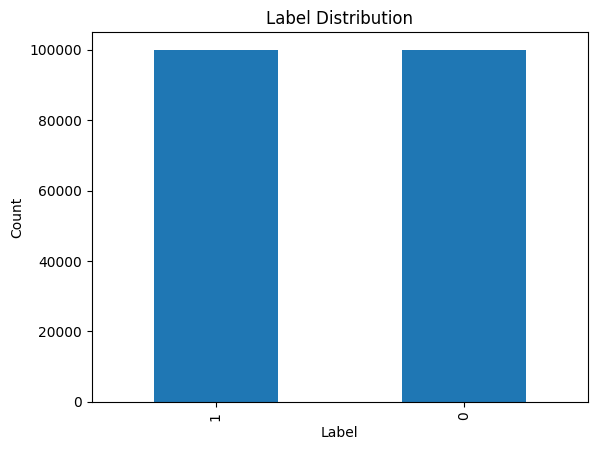

In [44]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


## 2. Malware Feature Engineering

Process EMBER malware features from raw JSONL files.

In [20]:
import json
import pandas as pd
from pathlib import Path

# Define project root (modify if you're outside a package/module)
project_root = Path().resolve().parent

# Set paths
malware_raw_dir = project_root / 'data' / 'malware' / 'raw'
malware_processed_dir = project_root / 'data' / 'malware' / 'processed'

input_path = malware_raw_dir / 'train_features_1.jsonl'
output_path = malware_processed_dir / 'ember_features.csv'

# Create output directory if not exists
malware_processed_dir.mkdir(parents=True, exist_ok=True)

In [22]:
# Processing logic
if input_path.exists():
    records = []
    skipped = 0

    with open(input_path, 'r') as f:
        for line in f:
            try:
                row = json.loads(line)

                # Required keys check
                if 'label' not in row or 'general' not in row or 'header' not in row:
                    skipped += 1
                    continue

                general = row.get('general', {})
                header = row.get('header', {})

                # Try alternate keys
                file_size = general.get('file_size')
                if file_size is None:
                    file_size = general.get('size')

                machine = header.get('machine')
                if machine is None:
                    machine = header.get('coff', {}).get('machine')

                characteristics = header.get('characteristics', [])
                coff_characteristics = header.get('coff', {}).get('characteristics', [])
                characteristics_count = len(characteristics) + len(coff_characteristics)

                histogram_sum = sum(row.get('histogram', []))

                entropy_vals = row.get('byteentropy', [])
                entropy_vals = [v for v in entropy_vals if isinstance(v, (int, float))]
                entropy_mean = sum(entropy_vals) / len(entropy_vals) if entropy_vals else 0

                record = {
                    'file_size': file_size,
                    'has_signature': general.get('has_signature', 0),
                    'machine': machine,
                    'characteristics_count': characteristics_count,
                    'histogram_sum': histogram_sum,
                    'entropy_mean': entropy_mean,
                    'label': row['label']
                }

                records.append(record)

            except Exception as e:
                skipped += 1
                continue

    # Create DataFrame
    # Filter out unknown labels

    df_malware = pd.DataFrame(records).dropna()
    df_malware = df_malware[df_malware['label'].isin([0, 1])]

    # Optional: enforce data types
    df_malware = df_malware.astype({
        'file_size': 'float',
        'has_signature': 'int',
        'machine': 'str',
        'characteristics_count': 'int',
        'histogram_sum': 'float',
        'entropy_mean': 'float',
        'label': 'int'
    })

    # Save to CSV
    df_malware.to_csv(output_path, index=False)

    # Summary
    print("\nLabel distribution (after filtering):")
    print(df_malware['label'].value_counts())

    print(f"✅ Saved {len(df_malware)} valid EMBER records to: {output_path}")
    print(f"⛔ Skipped {skipped} invalid or malformed lines")
    print(f"\nLabel distribution:\n{df_malware['label'].value_counts()}")
    print(f"\nPreview:\n{df_malware.head()}")


else:
    print(f"⚠️ Input file not found: {input_path}")


Label distribution (after filtering):
label
1    63713
0    52338
Name: count, dtype: int64
✅ Saved 116051 valid EMBER records to: D:\final_year_project\Qunatum-Enhanced_Threat_Intelligence\data\malware\processed\ember_features.csv
⛔ Skipped 0 invalid or malformed lines

Label distribution:
label
1    63713
0    52338
Name: count, dtype: int64

Preview:
   file_size  has_signature machine  characteristics_count  histogram_sum  \
0   349811.0              0    I386                      5       349811.0   
2   161280.0              0    I386                      3       161280.0   
3     6144.0              0    I386                      2         6144.0   
5  1130392.0              1    I386                      2      1130392.0   
6    73728.0              0    I386                      3        73728.0   

   entropy_mean  label  
0        2720.0      1  
2        1248.0      0  
3          40.0      0  
5        8816.0      1  
6         568.0      1  
